In [28]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import PIL
import random
import seaborn as sns
from pathlib import Path
import cv2


In [29]:
# Set random seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")

set_seed(42)

# Set device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

DATA_ROOT = r"D:\Uni\Lab\inebriation-voice-detector\data\processed"
TRAIN_DIR = os.path.join(DATA_ROOT, "TRAIN")
VAL_DIR = os.path.join(DATA_ROOT, "VALIDATION")
TEST_DIR = os.path.join(DATA_ROOT, "TEST")

# Create output directory
os.makedirs("output", exist_ok=True)

# Define classes
classes = ['SOBER', 'DRUNK']
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for idx, cls in enumerate(classes)}

Random seed set to 42
Using device: cuda:0


In [31]:
# ====================== DATA EXPLORATION ======================

def explore_dataset(data_dir, title):
    """Explore the dataset and visualize class distribution"""
    class_counts = {cls: 0 for cls in classes}
    file_paths = []
    labels = []
    
    # Count samples in each class
    for class_name in classes:
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.png'))]
            class_counts[class_name] = len(files)
            
            # Store file paths and labels for later use
            for file in files:
                file_paths.append(os.path.join(class_path, file))
                labels.append(class_to_idx[class_name])
    
    # Print statistics
    print(f"\n{title} Dataset Statistics:")
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} samples")
    print(f"  Total: {sum(class_counts.values())} samples")
    
    # Plot class distribution
    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.title(f"{title} Dataset Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Number of Samples")
    for i, count in enumerate(class_counts.values()):
        plt.text(i, count + 5, str(count), ha='center')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{title.lower()}_class_distribution.png"))
    plt.close()
    
    return file_paths, labels, class_counts

# Explore all datasets
train_files, train_labels, train_counts = explore_dataset(TRAIN_DIR, "Training")
val_files, val_labels, val_counts = explore_dataset(VAL_DIR, "Validation")
test_files, test_labels, test_counts = explore_dataset(TEST_DIR, "Test")


Training Dataset Statistics:
  SOBER: 5189 samples
  DRUNK: 2281 samples
  Total: 7470 samples

Validation Dataset Statistics:
  SOBER: 3741 samples
  DRUNK: 1573 samples
  Total: 5314 samples

Test Dataset Statistics:
  SOBER: 2187 samples
  DRUNK: 1858 samples
  Total: 4045 samples


In [32]:
# ====================== DATA VISUALIZATION ======================

def visualize_spectrograms(file_paths, labels, num_samples=5, save_path=None):
    """Visualize sample spectrograms from each class"""
    # Get sample images from each class
    samples_by_class = {cls: [] for cls in classes}
    for path, label in zip(file_paths, labels):
        class_name = idx_to_class[label]
        if len(samples_by_class[class_name]) < num_samples:
            samples_by_class[class_name].append(path)
    
    # Create subplot grid
    fig, axes = plt.subplots(len(classes), num_samples, figsize=(15, 5))
    
    for i, class_name in enumerate(classes):
        for j, img_path in enumerate(samples_by_class[class_name]):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_name}")
            axes[i, j].axis('off')
    
    plt.suptitle("Sample Spectrogram Images")
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    plt.close()

# Visualize sample spectrograms
visualize_spectrograms(
    train_files, 
    train_labels, 
    num_samples=5, 
    save_path=os.path.join(OUTPUT_DIR, "sample_spectrograms.png")
)

In [33]:
#Dataset Class
class SpectrogramDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = ['SOBER', 'DRUNK']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.samples = self._make_dataset()
        
    def _make_dataset(self):
        samples = []
        for class_name in os.listdir(self.root_dir):
            class_path = os.path.join(self.root_dir, class_name)
            if os.path.isdir(class_path):
                class_idx = self.class_to_idx[class_name]
                for filename in os.listdir(class_path):
                    if filename.endswith(('.jpg', '.jpeg', '.png')):
                        samples.append((
                            os.path.join(class_path, filename),
                            class_idx
                        ))
        return samples
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label



In [ ]:
# Data Preparation
# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize datasets

train_dataset = SpectrogramDataset(TRAIN_DIR, transform)
val_dataset = SpectrogramDataset(VAL_DIR, transform)
test_dataset = SpectrogramDataset(TEST_DIR, transform)

# Create balanced sampler
class_counts = torch.tensor([len([x for x in train_dataset.samples if x[1] == i]) for i in range(2)])
class_weights = 1. / class_counts
class_weights = class_weights / class_weights.sum()  # Normalize
sample_weights = torch.tensor([class_weights[y] for _, y in train_dataset.samples])
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create data loaders
BATCH_SIZE = 100
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [35]:
def create_model():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Unfreeze more layers
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer3.parameters():
        param.requires_grad = True
    for param in model.layer4.parameters():
        param.requires_grad = True
        
    # Better classifier head
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 1)
    )
    
    return model.to(device)

In [ ]:
#Loss Function

# Calculate weights based on actual class distribution
pos_weight = torch.tensor([class_counts[0]/class_counts[1]]).to(device)  # SOBER/DRUNK
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # Built-in version that handles imbalance better

In [ ]:
# Training Setup

optimizer = optim.Adam(model.parameters(), lr=0.001)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
# Modify early stopping
patience = 10  # Stop if no improvement for 10 epochs
num_epochs = 30
print("\nTraining setup:")
print("Optimizer: Adam(lr=0.001)")
print("LR scheduler: StepLR(step_size=10, gamma=0.1)")


Training setup:
Optimizer: Adam(lr=0.001)
LR scheduler: StepLR(step_size=10, gamma=0.1)


In [41]:


# Evaluation Function
def evaluate(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    running_loss = 0.0
    
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device).float()
            
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Calculate metrics
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    # Calculate UAR (Unweighted Average Recall)
    cm = confusion_matrix(all_labels, all_preds)
    if cm.shape == (2, 2):  # binary classification
        tn, fp, fn, tp = cm.ravel()
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        uar = (tpr + tnr) / 2
    else:  # handle case when one class is missing in predictions
        uar = accuracy_score(all_labels, all_preds)  # fallback
    
    metrics = {
        'loss': running_loss / len(data_loader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'uar': uar,
        'confusion_matrix': cm
    }
    
    return metrics


Epoch 1/30
----------


Training: 100%|██████████| 75/75 [00:21<00:00,  3.43it/s]


Train Loss: 0.9057 | Val Loss: 0.9654
Train Acc: 0.7048 | Val Acc: 0.6146
Train UAR: 0.7064 | Val UAR: 0.5970
Validation Confusion Matrix:
[[2395 1346]
 [ 702  871]]
Saved new best model (based on UAR)!

Epoch 2/30
----------


Training: 100%|██████████| 75/75 [00:16<00:00,  4.50it/s]


Train Loss: 0.8757 | Val Loss: 0.9599
Train Acc: 0.7527 | Val Acc: 0.6304
Train UAR: 0.7506 | Val UAR: 0.5866
Validation Confusion Matrix:
[[2596 1145]
 [ 819  754]]
No improvement in UAR for 1/5 epochs

Epoch 3/30
----------


...

Train Loss: 0.7684 | Val Loss: 0.9647
Train Acc: 0.9056 | Val Acc: 0.6227
Train UAR: 0.9059 | Val UAR: 0.5953
Validation Confusion Matrix:
[[2478 1263]
 [ 742  831]]
No improvement in UAR for 3/5 epochs

Epoch 10/30
----------


Training: 100%|██████████| 75/75 [00:12<00:00,  6.00it/s]


Train Loss: 0.7557 | Val Loss: 0.9688
Train Acc: 0.9270 | Val Acc: 0.6065
Train UAR: 0.9268 | Val UAR: 0.5942
Validation Confusion Matrix:
[[2336 1405]
 [ 686  887]]
No improvement in UAR for 4/5 epochs

Epoch 11/30
----------


Training: 100%|██████████| 75/75 [00:12<00:00,  5.98it/s]


Train Loss: 0.7451 | Val Loss: 0.9448
Train Acc: 0.9398 | Val Acc: 0.6603
Train UAR: 0.9398 | Val UAR: 0.6079
Validation Confusion Matrix:
[[2755  986]
 [ 819  754]]
No improvement in UAR for 5/5 epochs

Early stopping triggered after 5 epochs without improvement!

Training completed. Loaded best model weights.


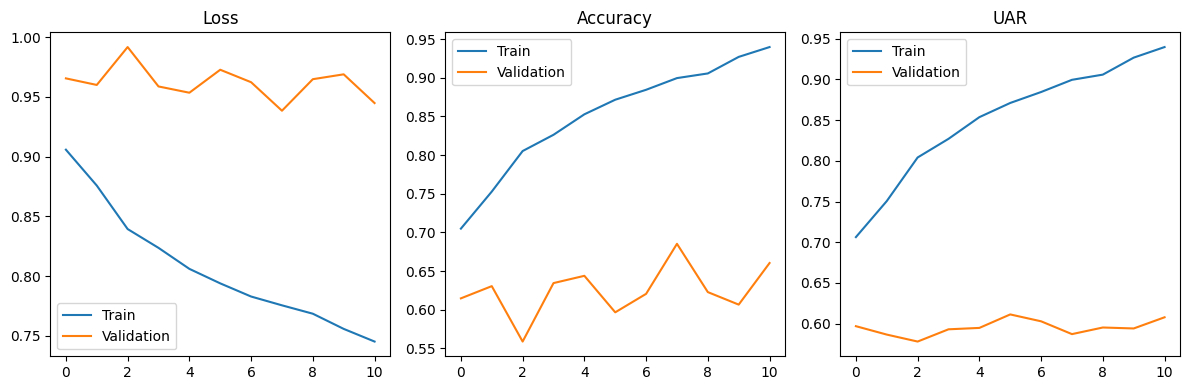


Final Test Results:
Accuracy: 0.5970
UAR: 0.6039
Confusion Matrix:
[[1136 1051]
 [ 579 1279]]


In [ ]:
# Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, num_epochs, patience):
    best_uar = 0
    no_improvement = 0
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_uar': [], 'val_uar': []
    }
    
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print("-" * 10)
        
        # Training phase
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        for inputs, labels in tqdm(train_loader, desc="Training"):
            inputs, labels = inputs.to(device), labels.to(device).float()
            
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(labels.cpu().numpy())
        
        # Calculate training metrics
        train_loss = train_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)
        
        # Calculate training UAR
        train_cm = confusion_matrix(train_labels, train_preds)
        if train_cm.shape == (2, 2):
            tn, fp, fn, tp = train_cm.ravel()
            tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            train_uar = (tpr + tnr) / 2
        else:
            train_uar = train_acc
        
        # Validation phase
        val_metrics = evaluate(model, val_loader)
        
        # Update LR scheduler
        scheduler.step()
        
        # Save history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_metrics['accuracy'])
        history['train_uar'].append(train_uar)
        history['val_uar'].append(val_metrics['uar'])
        
        # Print metrics
        print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f}")
        print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_metrics['accuracy']:.4f}")
        print(f"Train UAR: {train_uar:.4f} | Val UAR: {val_metrics['uar']:.4f}")
        print("Validation Confusion Matrix:")
        print(val_metrics['confusion_matrix'])
        
        # Early stopping check
        if val_metrics['uar'] > best_uar:
            best_uar = val_metrics['uar']
            no_improvement = 0
            torch.save(model.state_dict(), "output/best_model.pth")
            print("Saved new best model (based on UAR)!")
        else:
            no_improvement += 1
            print(f"No improvement in UAR for {no_improvement}/{patience} epochs")
            
            if no_improvement >= patience:
                print(f"\nEarly stopping triggered after {patience} epochs without improvement!")
                break
    
    # Load the best model weights before returning
    model.load_state_dict(torch.load("output/best_model.pth"))
    print("\nTraining completed. Loaded best model weights.")
    
    return history

# Train the model with early stopping
history = train_model(
    model, 
    train_loader, 
    val_loader, 
    num_epochs,
    patience  # Stop if no improvement for 5 epochs
)


# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history['train_uar'], label='Train')
plt.plot(history['val_uar'], label='Validation')
plt.title('UAR')
plt.legend()

plt.tight_layout()
plt.savefig("output/training_curves.png")
plt.show()
# ======== END VISUALIZATION ========

# Load best model and evaluate on test set
model.load_state_dict(torch.load("output/best_model.pth"))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])


Final Test Results:
Loss: 0.9831
Accuracy: 0.5970
UAR: 0.6039
Confusion Matrix:
[[1136 1051]
 [ 579 1279]]


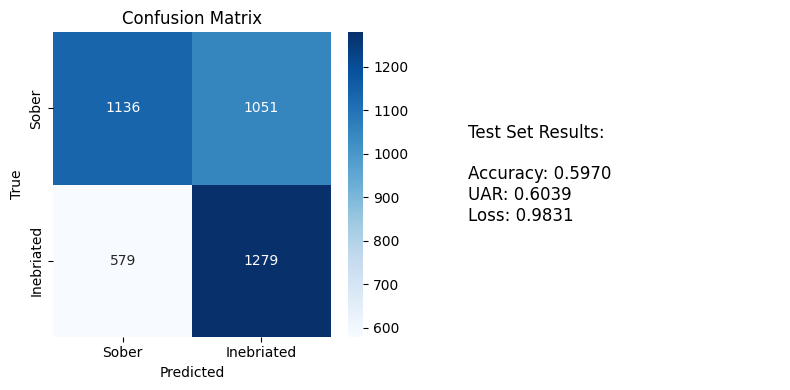

In [43]:
def plot_results(metrics, class_names):
    plt.figure(figsize=(8, 4))
    
    # Confusion matrix
    plt.subplot(1, 2, 1)
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', 
                cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    
    # Metrics summary
    plt.subplot(1, 2, 2)
    plt.axis('off')
    metrics_text = (
        "Test Set Results:\n\n"
        f"Accuracy: {metrics['accuracy']:.4f}\n"
        f"UAR: {metrics['uar']:.4f}\n"
        f"Loss: {metrics['loss']:.4f}\n"
    )
    plt.text(0.1, 0.5, metrics_text, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig("output/test_results.png")
    plt.show()

# Load best model and evaluate
model.load_state_dict(torch.load("output/best_model.pth"))
test_metrics = evaluate(model, test_loader)

print("\nFinal Test Results:")
print(f"Loss: {test_metrics['loss']:.4f}")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(f"UAR: {test_metrics['uar']:.4f}")
print("Confusion Matrix:")
print(test_metrics['confusion_matrix'])

# Plot results
plot_results(test_metrics, ['Sober', 'Inebriated'])  # Replace with your actual class names
